# Supplement: Stability analysis

## Instructions

Make sure the data is downloaded first (also see `01_exp_regression.ipynb`):

```bash
DATA_DIR=../data/raw/multiomics
mkdir -p $DATA_DIR
micromamba -n nedis run wget https://zenodo.org/records/10545240/files/multiomics.rda -O ${DATA_DIR}/multiomics.rda
```

Then run `05.07_supplement_exp_regression_stable_run.sh` in three times with the following parameters:

- Run 1: `drop_entities = [1,2,3,4,5,6,7,8,9,10]`
- Run 2: `drop_samples = [4,8,12,16,20,24,28,32,36,40]`
- Run 3: `drop_features=("0" "10" "20" "30" "40" "50" "60" "70" "80" "90" "100")`

Keep the following parameters the same:

- `n_repeats=5`
- `seeds=("120")`
- `bootstrap_iterations=("1000")`
- `bootstrap_thresholds=("0.7")`

## Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from nedis.parallelization import set_threads_for_external_libraries
set_threads_for_external_libraries(16)

In [3]:
import sys
import logging
import re

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import seaborn as sns

import sklearn.cluster
import pathlib

In [4]:
import nedis.data.synthetic
import nedis.data.tasks

from nedis.experiments import load_component
from nedis.visualization import grouped_spline_plot

## Setup

In [5]:
%run -m rpy2.situation

rpy2 version:
3.4.5
Python version:
3.10.8 | packaged by conda-forge | (main, Nov 22 2022, 08:23:14) [GCC 10.4.0]
Looking for R's HOME:
    Environment variable R_HOME: None
    Calling `R RHOME`: /mnt/scratch/mgbckr/micromamba/envs/nalab-cordis-publication2/lib/R
    Environment variable R_LIBS_USER: None
R's additions to LD_LIBRARY_PATH:

R version:
    In the PATH: R version 4.1.2 (2021-11-01) -- "Bird Hippie"
    Loading R library from rpy2: OK
Additional directories to load R packages from:
None
C extension compilation:
  include:
  ['/mnt/scratch/mgbckr/micromamba/envs/nalab-cordis-publication2/lib/R/include']
  libraries:
  ['R', 'pcre2-8', 'lzma', 'bz2', 'z', 'rt', 'dl', 'm', 'iconv', 'icuuc', 'icui18n']
  library_dirs:
  ['/mnt/scratch/mgbckr/micromamba/envs/nalab-cordis-publication2/lib', '/mnt/scratch/mgbckr/micromamba/envs/nalab-cordis-publication2/lib/R/lib', '/mnt/scratch/mgbckr/micromamba/envs/nalab-cordis-publication2/lib']
  extra_compile_args:
  []
  extra_link_args:


In [6]:
logging.basicConfig(stream=sys.stdout)
logging.getLogger("nedis").setLevel(level=logging.DEBUG)

## Parameters

In [ ]:
# parameters (papermill)
prefix = None
task_id = "multiomics-immune-system-pp-first-ref-all-all"
transformer_id = "default"
handle_heteroscedasticity = "robust"
groups = True
random_state = 120
# random_state = 122

# algorithm parameters
resolution_parameter = 1.3

# dropping parameters
n_entities_to_drop = 0
n_samples_to_drop = 0
n_features_to_drop = 0

bootstrap_iterations = 1000
bootstrap_threshold = 0.7

# postfix
postfix = "repeat-1"

In [35]:
# set experiment name
def get_exp_name(
    prefix=prefix,
    resolution_parameter=resolution_parameter,
    n_entities_to_drop=n_entities_to_drop,
    n_samples_to_drop=n_samples_to_drop,
    n_features_to_drop=n_features_to_drop,
    bootstrap_iterations=bootstrap_iterations,
    bootstrap_threshold=bootstrap_threshold,
    random_state=random_state,
    postfix=postfix,
):

    exp_name = f"stability___regression"

    if prefix is not None:
        exp_name += f"___prefix_{prefix}"

    exp_name = exp_name \
        + f"___params" \
        # + f"___transformer_{transformer_id}" \
        # + f"___task_{task_name}" \
        # + f"___handle-heteroscedasticity_{handle_heteroscedasticity}"

    # if groups:
    #     exp_name += f"___groups_{groups}"

    if resolution_parameter != 1.3:
        exp_name += f"___res_{resolution_parameter}"

    exp_name += f"___drop-entities_{n_entities_to_drop}"
    exp_name += f"___drop-samples_{n_samples_to_drop}"
    exp_name += f"___drop-features_{n_features_to_drop}"

    exp_name += f"___bootstrap-iterations_{bootstrap_iterations}"
    if bootstrap_threshold is not None:
        exp_name += f"___bootstrap-threshold_{bootstrap_threshold}"
    else:
        exp_name += f"___bootstrap-threshold_none"
    
        
    exp_name += f"___random-state_{random_state}"

    if postfix is not None:
        exp_name += f"___postfix_{postfix}"
        
    print(exp_name)
    return exp_name

exp_name = get_exp_name()

stability___regression___params___drop-entities_0___drop-samples_0___drop-features_0___bootstrap-iterations_1000___bootstrap-threshold_-1___random-state_120___postfix_repeat-1


## Cluster visualization

In [31]:
def load_exp(exp_name):
    exp_dir = pathlib.Path("../_out/realworld") / exp_name
    transformer = load_component("transformer", output_dir=exp_dir, verbose=False)
    return {
        "t": transformer,
        "y": load_component("y", output_dir=exp_dir, verbose=False),
        "feature_names": load_component("feature_names", output_dir=exp_dir, verbose=False),
        "clusters": sorted(transformer.clusters_, key=lambda c: -c["reference_score"]),
        "coordinates_dict": load_component("coordinates_dict", output_dir=exp_dir, verbose=False),
        "correlation_matrices_dict": load_component("correlation_matrices_dict", output_dir=exp_dir, verbose=False),
        "disruption_matrices_dict": load_component("disruption_matrices_dict", output_dir=exp_dir, verbose=False),
        "exp_dir": exp_dir
    }

exp = load_exp(get_exp_name())

Experiment:
stability___regression___params___drop-entities_0___drop-samples_0___drop-features_0___bootstrap-iterations_1000___bootstrap-threshold_-1___random-state_120___postfix_repeat-1


In [13]:
def metric(a, b):
    a, b = set(a), set(b)
    return len(a & b) / len(a | b) if a | b else 0.0

In [32]:
ref_config = {
    "bootstrap_iterations": 1000,
    "bootstrap_threshold": 0.7
}
ref = load_exp(get_exp_name(**ref_config))

Experiment:
stability___regression___params___drop-entities_0___drop-samples_0___drop-features_0___bootstrap-iterations_1000___bootstrap-threshold_0.7___random-state_120___postfix_repeat-1


In [29]:
ref_features = ref["feature_names"][ref["clusters"][1]["rows"]]
ref_features

array(['37_cMCs_STAT1_IFNa100', '41_mDCs_STAT1_IFNa100',
       '50_Bcells_STAT3_IFNa100', '51_CD16+CD56-NKcells_STAT3_IFNa100',
       '52_CD4+Tcells_mem_STAT3_IFNa100',
       '53_CD4+Tcells_naive_STAT3_IFNa100', '54_CD4+Tcells_STAT3_IFNa100',
       '55_CD45RA+Tregs_STAT3_IFNa100', '56_CD45RA-Tregs_STAT3_IFNa100',
       '57_CD56+CD16-NKcells_STAT3_IFNa100',
       '58_CD7+NKcells_STAT3_IFNa100', '59_CD8+Tcells_mem_STAT3_IFNa100',
       '61_CD8+Tcells_STAT3_IFNa100', '62_cMCs_STAT3_IFNa100',
       '70_Tbet+CD4+Tcells_naive_STAT3_IFNa100',
       '73_TCRgd+Tcells_STAT3_IFNa100', '74_Tregs_STAT3_IFNa100',
       '156_CD45RA-Tregs_STAT3_IL100', '168_pDCs_STAT3_IL100',
       '174_Tregs_STAT3_IL100', '181_CD45RA-Tregs_STAT5_IL100',
       '185_CD8+Tcells_naive_STAT5_IL100',
       '196_Tbet+CD8+Tcells_mem_STAT5_IL100',
       '197_Tbet+CD8+Tcells_naive_STAT5_IL100',
       '198_TCRgd+Tcells_STAT5_IL100',
       '203_CD56+CD16-NKcells_CREB_LPS100'], dtype='<U41')

In [33]:
repeats = [1,2,3,4,5]
refs = [load_exp(get_exp_name(postfix=f"repeat-{r}", **ref_config)) for r in repeats]

Experiment:
stability___regression___params___drop-entities_0___drop-samples_0___drop-features_0___bootstrap-iterations_1000___bootstrap-threshold_0.7___random-state_120___postfix_repeat-1
Experiment:
stability___regression___params___drop-entities_0___drop-samples_0___drop-features_0___bootstrap-iterations_1000___bootstrap-threshold_0.7___random-state_120___postfix_repeat-2
Experiment:
stability___regression___params___drop-entities_0___drop-samples_0___drop-features_0___bootstrap-iterations_1000___bootstrap-threshold_0.7___random-state_120___postfix_repeat-3
Experiment:
stability___regression___params___drop-entities_0___drop-samples_0___drop-features_0___bootstrap-iterations_1000___bootstrap-threshold_0.7___random-state_120___postfix_repeat-4
Experiment:
stability___regression___params___drop-entities_0___drop-samples_0___drop-features_0___bootstrap-iterations_1000___bootstrap-threshold_0.7___random-state_120___postfix_repeat-5


In [ ]:
n_rep = 5
drop_entities = [1,2,3,4,5,6,7,8,9,10]
exps_entities = {}
for n in drop_entities:
    exps_entities[n] = []
    for r in np.arange(n_rep):
        exp_name = get_exp_name(n_entities_to_drop=n, postfix=f"repeat-{r+1}", **ref_config)
        try:
            exps_entities[n].append(load_exp(exp_name))
        except Exception as e:
            print(f"    FAILED: Could not load experiment: {exp_name} because of {e}")
print(sum(len(v) for v in exps_entities.values()))

stability___regression___params___drop-entities_1___drop-samples_0___drop-features_0___bootstrap-iterations_1000___bootstrap-threshold_0.7___random-state_120___postfix_repeat-1
stability___regression___params___drop-entities_1___drop-samples_0___drop-features_0___bootstrap-iterations_1000___bootstrap-threshold_0.7___random-state_120___postfix_repeat-2
stability___regression___params___drop-entities_1___drop-samples_0___drop-features_0___bootstrap-iterations_1000___bootstrap-threshold_0.7___random-state_120___postfix_repeat-3
stability___regression___params___drop-entities_1___drop-samples_0___drop-features_0___bootstrap-iterations_1000___bootstrap-threshold_0.7___random-state_120___postfix_repeat-4
stability___regression___params___drop-entities_1___drop-samples_0___drop-features_0___bootstrap-iterations_1000___bootstrap-threshold_0.7___random-state_120___postfix_repeat-5
stability___regression___params___drop-entities_2___drop-samples_0___drop-features_0___bootstrap-iterations_1000___

In [ ]:
n_rep = 5
drop_samples = [4,8,12,16,20,24,28,32,36,40]
exps_samples = {}
for n in drop_samples:
    exps_samples[n] = []
    for r in np.arange(n_rep):
        exp_name = get_exp_name(n_samples_to_drop=n, postfix=f"repeat-{r+1}", **ref_config)
        try:
            exps_samples[n].append(load_exp(exp_name))
        except Exception as e:
            print(f"    FAILED: Could not load experiment: {exp_name} because of {e}")
print(sum(len(v) for v in exps_samples.values()))

stability___regression___params___drop-entities_0___drop-samples_4___drop-features_0___bootstrap-iterations_1000___bootstrap-threshold_0.7___random-state_120___postfix_repeat-1
stability___regression___params___drop-entities_0___drop-samples_4___drop-features_0___bootstrap-iterations_1000___bootstrap-threshold_0.7___random-state_120___postfix_repeat-2
stability___regression___params___drop-entities_0___drop-samples_4___drop-features_0___bootstrap-iterations_1000___bootstrap-threshold_0.7___random-state_120___postfix_repeat-3
stability___regression___params___drop-entities_0___drop-samples_4___drop-features_0___bootstrap-iterations_1000___bootstrap-threshold_0.7___random-state_120___postfix_repeat-4
stability___regression___params___drop-entities_0___drop-samples_4___drop-features_0___bootstrap-iterations_1000___bootstrap-threshold_0.7___random-state_120___postfix_repeat-5
stability___regression___params___drop-entities_0___drop-samples_8___drop-features_0___bootstrap-iterations_1000___

In [ ]:
n_rep = 5
drop_features = [10,20,30,40,50,60,70,80,90,100]
exps_features = {}
for n in drop_features:
    exps_features[n] = []
    for r in np.arange(n_rep):
        exp_name = get_exp_name(n_features_to_drop=n, postfix=f"repeat-{r+1}", **ref_config)
        try:
            exps_features[n].append(load_exp(exp_name))
        except Exception as e:
            print(f"    FAILED: Could not load experiment: {exp_name} because of {e}")

print(sum(len(v) for v in exps_features.values()))

stability___regression___params___drop-entities_0___drop-samples_0___drop-features_10___bootstrap-iterations_1000___bootstrap-threshold_0.7___random-state_120___postfix_repeat-1
stability___regression___params___drop-entities_0___drop-samples_0___drop-features_10___bootstrap-iterations_1000___bootstrap-threshold_0.7___random-state_120___postfix_repeat-2
stability___regression___params___drop-entities_0___drop-samples_0___drop-features_10___bootstrap-iterations_1000___bootstrap-threshold_0.7___random-state_120___postfix_repeat-3
stability___regression___params___drop-entities_0___drop-samples_0___drop-features_10___bootstrap-iterations_1000___bootstrap-threshold_0.7___random-state_120___postfix_repeat-4
stability___regression___params___drop-entities_0___drop-samples_0___drop-features_10___bootstrap-iterations_1000___bootstrap-threshold_0.7___random-state_120___postfix_repeat-5
stability___regression___params___drop-entities_0___drop-samples_0___drop-features_20___bootstrap-iterations_1

In [106]:
def jaccard_index(a, b):
    a, b = set(a), set(b)
    return len(a & b) / len(a | b) if a | b else 0.0

In [107]:
def containb(a, b):
    a, b = set(a), set(b)
    return len(a & b) / len(b) if a | b else 0.0

In [108]:
def containa(a, b):
    a, b = set(a), set(b)
    return len(a & b) / len(a) if a | b else 0.0

In [109]:
metric = containb

In [ ]:
def plot(exps, label, ax=None):

    values = []
    for exp in refs:
        cluster_values = []
        for c in exp["clusters"]:
            value = metric(ref_features, exp["feature_names"][c["rows"]])
            cluster_values.append(value)
        max_value = max(cluster_values)
        values.append((0, max_value))

    for e, exp in exps.items():
        for r in exp:
            cluster_values = []
            for c in r["clusters"]:
                value = metric(ref_features, r["feature_names"][c["rows"]])
                cluster_values.append(value)
            max_value = max(cluster_values) 
            values.append((e, max_value))

    values = np.array(values)

    if ax is None:
        fig, ax = plt.subplots(figsize=(6,4))
    sns.boxplot(x=values[:,0].astype(int), y=values[:,1], color="C0", ax=ax)
    ax.set(
        ylabel="Maximum cover",
        ylim=(0,1.1)
    )
    ax.set_title(label, fontsize=14)


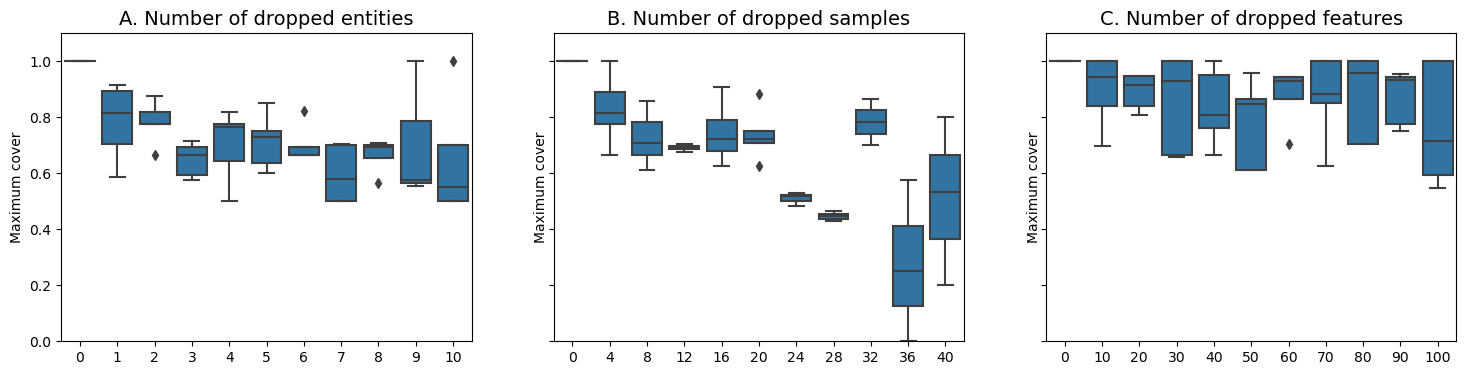

In [157]:
fig, ax = plt.subplots(1, 3, figsize=(6*3,4), sharey=True)
plot(exps_entities, "A. Number of dropped entities", ax=ax[0])
plot(exps_samples, "B. Number of dropped samples", ax=ax[1])
plot(exps_features, "C. Number of dropped features", ax=ax[2])
fig.savefig("../_out/paper/stability_evaluation.png", dpi=300, bbox_inches='tight')
fig.savefig("../_out/paper/stability_evaluation.pdf", dpi=300, bbox_inches='tight')

In [ ]:
print("Done")